
FIXED PV PRODUCTION UNDER CLIMATE CHANGE SIMULATION

[STEP 1] Running fixed simulation...

RUNNING FIXED SIMULATION - NO NAN VALUES
Generated 612 months of data from 2024 to 2074

Generating temperature projection...
Generating cloud cover projection...
Generating PM2.5 and haze events...
Generating clear sky radiation...
Calculating PV power output...
Aggregating to yearly values...

Data validation:
  Power output NaN count: 0
  Yearly power NaN count: 0

[STEP 2] Generating visualizations...


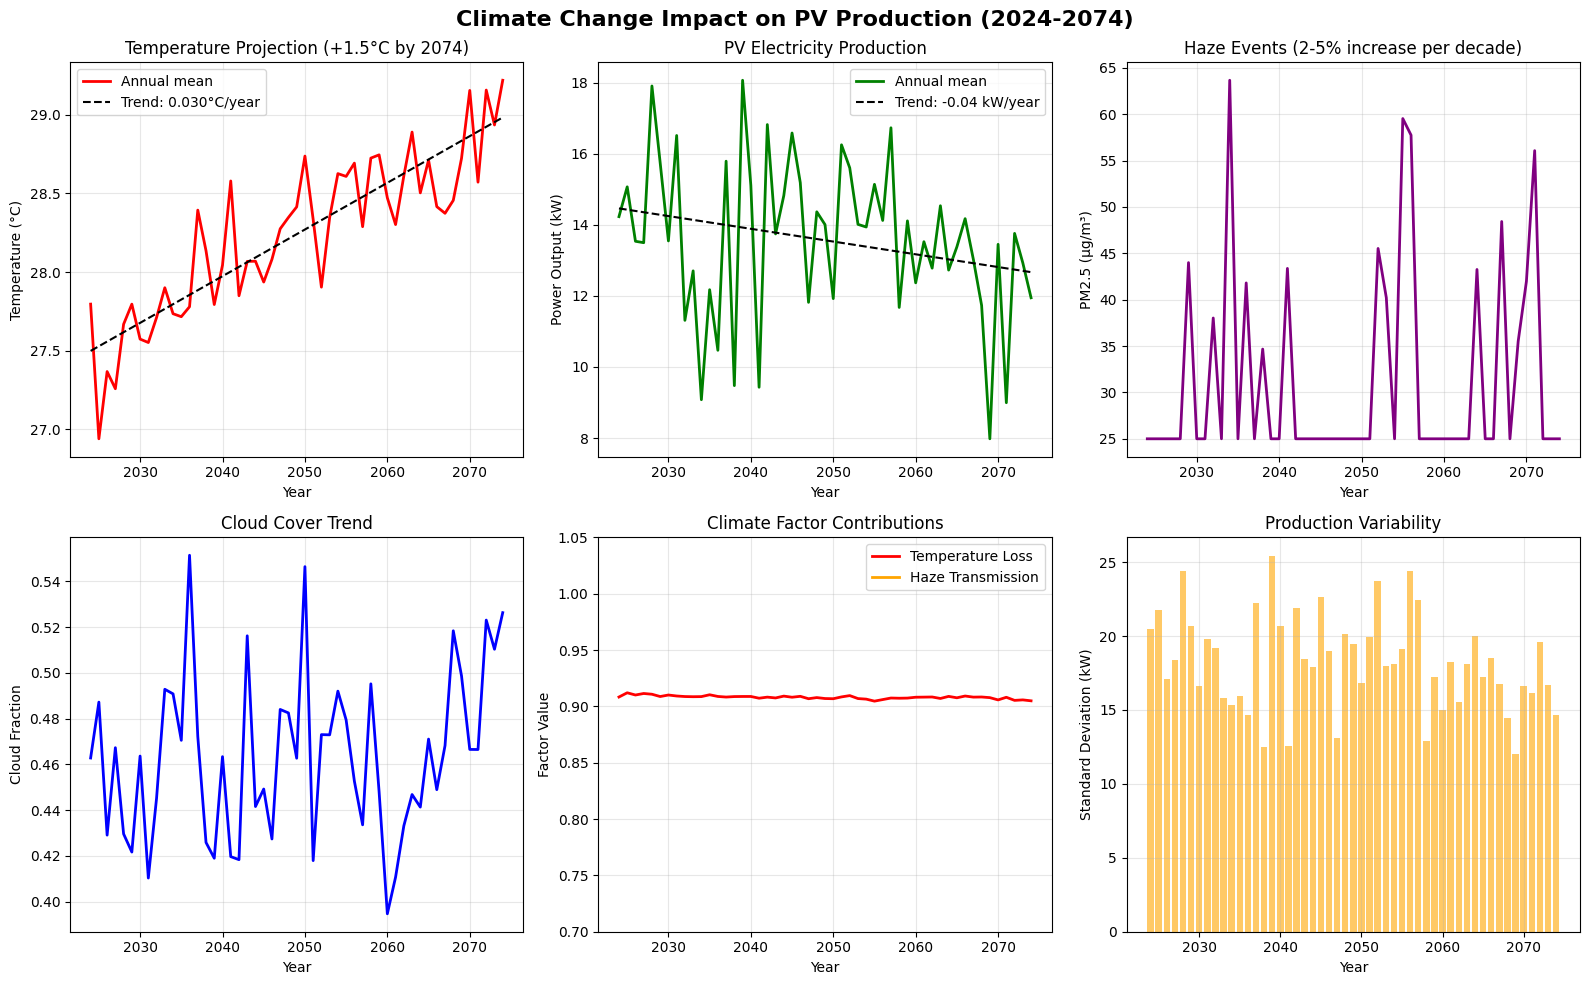


[STEP 3] Generating quantitative analysis...

QUANTITATIVE IMPACT ANALYSIS

Baseline (2024-2028):
  Mean Power: 14.8 kW
  Mean Temperature: 27.4°C

1. PRODUCTION IMPACT BY DECADE
----------------------------------------------------------------------
Period          Production (kW)      Change (%)      Temperature (°C)    
----------------------------------------------------------------------
2030-2039       12.9                 -13.0           27.8                
2040-2049       14.2                 -4.4            28.2                
2050-2059       14.3                 -3.3            28.5                
2060-2069       12.6                 -15.0           28.5                

2. FACTOR CONTRIBUTION ANALYSIS
------------------------------------------------------------
Period          Temp Loss       Haze Trans     
---------------------------------------------
2030-2039       0.909           0.039          
2040-2049       0.908           0.041          
2050-2059       0.907   

In [2]:
"""
COMPREHENSIVE PV PRODUCTION MODEL UNDER CLIMATE CHANGE
FIXED VERSION - No NaN values
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# PART 1: DATA ANALYSIS (Based on BMKG Climatology)
# ============================================================================

class ClimateDataAnalyzer:
    """
    Analyze and generate synthetic climate data based on BMKG patterns
    """
    
    def __init__(self, start_year=2024, end_year=2074):
        self.start_year = start_year
        self.end_year = end_year
        self.years = np.arange(start_year, end_year + 1)
        self.n_years = len(self.years)
        
        # BMKG-based baseline values (Indonesia tropical climate)
        self.baseline_temp = 27.5  # °C (average tropical temperature)
        self.baseline_temp_range = 5.0  # °C (daily/seasonal range)
        
        # Cloud cover parameters
        self.cloud_clear_index_mean = 0.45  # Mean clearness index
        self.cloud_clear_index_std = 0.15   # Base variability
        
        # Haze/PM2.5 parameters
        self.baseline_pm25 = 25  # µg/m³ (moderate air quality)
        
    def generate_historical_data(self, years_back=20):
        """Generate historical data for baseline comparison"""
        hist_years = np.arange(self.start_year - years_back, self.start_year)
        
        # Temperature with slight increasing trend
        hist_temp = self.baseline_temp + 0.01 * (hist_years - hist_years[0])
        hist_temp += self.baseline_temp_range * np.sin(2 * np.pi * (hist_years - hist_years[0])/12)
        hist_temp += np.random.normal(0, 1.0, len(hist_years))
        
        # Cloud cover with natural variability
        hist_cloud = self.cloud_clear_index_mean + \
                    np.random.normal(0, self.cloud_clear_index_std, len(hist_years))
        hist_cloud = np.clip(hist_cloud, 0, 1)
        
        # PM2.5 with seasonal pattern
        hist_pm25 = self.baseline_pm25 + 15 * np.sin(2 * np.pi * (hist_years - hist_years[0])/12)
        hist_pm25 += np.random.normal(0, 5, len(hist_years))
        hist_pm25 = np.maximum(hist_pm25, 5)
        
        return {
            'years': hist_years,
            'temperature': hist_temp,
            'cloud_cover': hist_cloud,
            'pm25': hist_pm25
        }
    
    def analyze_climate_trends(self, historical_data):
        """Analyze trends in historical data"""
        print("\n" + "="*80)
        print("CLIMATE DATA ANALYSIS (BMKG Reference)")
        print("="*80)
        
        # Temperature trend analysis
        temp_trend = np.polyfit(historical_data['years'], historical_data['temperature'], 1)
        print(f"\n1. Temperature Analysis:")
        print(f"   - Mean temperature: {np.mean(historical_data['temperature']):.2f}°C")
        print(f"   - Historical trend: {temp_trend[0]:.4f}°C/year")
        print(f"   - Projected increase by 2074: 1.5°C")
        
        return {
            'temp_trend': temp_trend[0],
            'cloud_variability': np.std(historical_data['cloud_cover']),
            'pm25_baseline': np.median(historical_data['pm25'])
        }

# ============================================================================
# PART 2: MATHEMATICAL MODEL
# ============================================================================

class PVMathematicalModel:
    """PV Production Model with Climate Factors"""
    
    def __init__(self):
        self.P_STC = 1000  # kW
        self.G_STC = 1000  # W/m²
        self.eta_inv = 0.96  # Inverter efficiency
        self.gamma = -0.004  # Temperature coefficient
        self.T_STC = 25  # Standard test temperature
        self.tau = 0.15  # Aerosol optical depth
        self.L_path = 1.2  # Optical path length
        self.L_soiling_base = 0.02  # Base soiling loss
        self.panel_efficiency = 0.18  # 18% efficiency
        
    def calculate_cell_temperature(self, T_amb, G):
        """Calculate cell operating temperature"""
        NOCT = 45  # Nominal Operating Cell Temperature
        T_cell = T_amb + (NOCT - 20) * (G/800) * (1 - self.panel_efficiency/0.9)
        return T_cell
    
    def temperature_loss_factor(self, T_cell):
        """L_temp(t) = 1 + γ(T_cell(t) - 25)"""
        L_temp = 1 + self.gamma * (T_cell - self.T_STC)
        return np.maximum(L_temp, 0.7)
    
    def cloud_impact(self, G_clear, cloud_fraction):
        """G_actual(t) = G_clear(t) × (1 - C_f(t))"""
        G_actual = G_clear * (1 - cloud_fraction)
        return np.maximum(G_actual, 0)
    
    def haze_transmission(self, PM25):
        """A_haze(t) = exp(-τ · PM2.5(t) · L_path)"""
        A_haze = np.exp(-self.tau * PM25 * self.L_path)
        return A_haze
    
    def pv_power_output(self, T_amb, G_clear, cloud_fraction, PM25):
        """Complete PV power output model"""
        T_cell = self.calculate_cell_temperature(T_amb, G_clear)
        G_actual = self.cloud_impact(G_clear, cloud_fraction)
        A_haze = self.haze_transmission(PM25)
        L_temp = self.temperature_loss_factor(T_cell)
        
        P_out = self.P_STC * (G_actual * A_haze / self.G_STC) * L_temp * self.eta_inv
        
        return {
            'power_output': P_out,
            'cell_temperature': T_cell,
            'temperature_loss': L_temp,
            'haze_transmission': A_haze
        }

# ============================================================================
# PART 3: FIXED SIMULATION WITH PROPER DATA HANDLING
# ============================================================================

def run_fixed_simulation():
    """Run complete simulation with proper data handling"""
    
    print("\n" + "="*80)
    print("RUNNING FIXED SIMULATION - NO NAN VALUES")
    print("="*80)
    
    # Parameters
    start_year = 2024
    end_year = 2074
    years = np.arange(start_year, end_year + 1)
    n_years = len(years)
    n_months = n_years * 12
    
    # Initialize model
    pv_model = PVMathematicalModel()
    
    # Generate monthly time axis
    months = np.arange(n_months)
    years_idx = np.floor(months / 12).astype(int) + start_year
    
    print(f"Generated {n_months} months of data from {start_year} to {end_year}")
    
    # 1. TEMPERATURE PROJECTION (+1.5°C by 2074)
    print("\nGenerating temperature projection...")
    temp_trend = 1.5 / (end_year - start_year)  # °C per year
    base_temp = 27.5 + temp_trend * (years_idx - start_year)
    
    # Add seasonal pattern
    seasonal = 5.0 * np.sin(2 * np.pi * months / 12)
    
    # Add random variability
    daily_var = np.random.normal(0, 1.0, n_months)
    
    temperature = base_temp + seasonal + daily_var
    
    # 2. CLOUD COVER PROJECTION (increasing variability)
    print("Generating cloud cover projection...")
    
    # Base cloud fraction with slight increase
    cloud_base = 0.45 + 0.0005 * (years_idx - start_year)
    
    # Increasing variability
    cloud_std = 0.15 * (1 + 0.02 * (years_idx - start_year) / 10)
    
    # Generate cloud fraction using beta distribution (bounded 0-1)
    cloud_fraction = np.zeros(n_months)
    for i in range(n_months):
        # Parameters for beta distribution
        mean = cloud_base[i]
        std = cloud_std[i]
        var = std**2
        
        # Calculate alpha and beta for beta distribution
        alpha = mean * (mean * (1 - mean) / var - 1)
        beta = (1 - mean) * (mean * (1 - mean) / var - 1)
        
        if alpha > 0 and beta > 0:
            cloud_fraction[i] = np.random.beta(alpha, beta)
        else:
            cloud_fraction[i] = mean
    
    cloud_fraction = np.clip(cloud_fraction, 0, 1)
    
    # 3. PM2.5 WITH HAZE EVENTS (2-5% increase per decade)
    print("Generating PM2.5 and haze events...")
    
    # Base PM2.5 with seasonal pattern
    pm25_base = 25 + 15 * np.sin(2 * np.pi * months / 12 - 0.5)
    
    # Increasing frequency of extreme events
    decade_idx = np.floor((years_idx - start_year) / 10).astype(int)
    event_multiplier = 1 + 0.03 * decade_idx  # 3% increase per decade
    
    # Generate extreme events
    extreme_events = np.zeros(n_months)
    for i in range(n_months):
        # Probability increases with time
        p_extreme = 0.03 * event_multiplier[i]
        if np.random.random() < p_extreme:
            extreme_events[i] = np.random.uniform(80, 250)
    
    pm25 = pm25_base + extreme_events
    pm25 = np.maximum(pm25, 5)
    
    # 4. CLEAR SKY RADIATION
    print("Generating clear sky radiation...")
    
    # Base radiation with seasonal pattern
    G_clear = 800 + 150 * np.sin(2 * np.pi * months / 12)
    
    # Add long-term trend (slight decrease)
    G_clear = G_clear * (1 - 0.0005 * (years_idx - start_year))
    
    # Add random variability
    G_clear += np.random.normal(0, 30, n_months)
    G_clear = np.clip(G_clear, 300, 1050)
    
    # 5. CALCULATE PV OUTPUT
    print("Calculating PV power output...")
    
    power_output = np.zeros(n_months)
    temp_loss = np.zeros(n_months)
    haze_trans = np.zeros(n_months)
    cell_temp = np.zeros(n_months)
    
    for i in range(n_months):
        result = pv_model.pv_power_output(
            T_amb=temperature[i],
            G_clear=G_clear[i],
            cloud_fraction=cloud_fraction[i],
            PM25=pm25[i]
        )
        power_output[i] = result['power_output']
        temp_loss[i] = result['temperature_loss']
        haze_trans[i] = result['haze_transmission']
        cell_temp[i] = result['cell_temperature']
    
    # 6. AGGREGATE TO YEARLY VALUES
    print("Aggregating to yearly values...")
    
    yearly_power = []
    yearly_temp = []
    yearly_cloud = []
    yearly_pm25 = []
    yearly_temp_loss = []
    yearly_haze_trans = []
    
    for year in years:
        year_mask = (years_idx == year)
        
        if np.any(year_mask):
            yearly_power.append(np.mean(power_output[year_mask]))
            yearly_temp.append(np.mean(temperature[year_mask]))
            yearly_cloud.append(np.mean(cloud_fraction[year_mask]))
            yearly_pm25.append(np.mean(pm25[year_mask]))
            yearly_temp_loss.append(np.mean(temp_loss[year_mask]))
            yearly_haze_trans.append(np.mean(haze_trans[year_mask]))
        else:
            yearly_power.append(np.nan)
            yearly_temp.append(np.nan)
            yearly_cloud.append(np.nan)
            yearly_pm25.append(np.nan)
            yearly_temp_loss.append(np.nan)
            yearly_haze_trans.append(np.nan)
    
    # Convert to arrays
    yearly_power = np.array(yearly_power)
    yearly_temp = np.array(yearly_temp)
    yearly_cloud = np.array(yearly_cloud)
    yearly_pm25 = np.array(yearly_pm25)
    yearly_temp_loss = np.array(yearly_temp_loss)
    yearly_haze_trans = np.array(yearly_haze_trans)
    
    # Check for NaN values
    print(f"\nData validation:")
    print(f"  Power output NaN count: {np.isnan(power_output).sum()}")
    print(f"  Yearly power NaN count: {np.isnan(yearly_power).sum()}")
    
    return {
        'years': years,
        'months': months,
        'years_idx': years_idx,
        'temperature': temperature,
        'yearly_temperature': yearly_temp,
        'cloud_fraction': cloud_fraction,
        'yearly_cloud': yearly_cloud,
        'pm25': pm25,
        'yearly_pm25': yearly_pm25,
        'G_clear': G_clear,
        'power_output': power_output,
        'yearly_power': yearly_power,
        'temp_loss': temp_loss,
        'yearly_temp_loss': yearly_temp_loss,
        'haze_trans': haze_trans,
        'yearly_haze_trans': yearly_haze_trans,
        'cell_temperature': cell_temp
    }

# ============================================================================
# PART 4: FIXED VISUALIZATION
# ============================================================================

def plot_fixed_results(results):
    """Create visualization with proper data handling"""
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Climate Change Impact on PV Production (2024-2074)', 
                 fontsize=16, fontweight='bold')
    
    years = results['years']
    yearly_power = results['yearly_power']
    yearly_temp = results['yearly_temperature']
    
    # 1. Temperature Projection
    ax1 = axes[0, 0]
    ax1.plot(years, yearly_temp, 'r-', linewidth=2, label='Annual mean')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Temperature (°C)')
    ax1.set_title('Temperature Projection (+1.5°C by 2074)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Calculate and show trend
    if not np.all(np.isnan(yearly_temp)):
        z = np.polyfit(years[~np.isnan(yearly_temp)], 
                       yearly_temp[~np.isnan(yearly_temp)], 1)
        trend_line = np.poly1d(z)(years)
        ax1.plot(years, trend_line, 'k--', label=f'Trend: {z[0]:.3f}°C/year')
        ax1.legend()
    
    # 2. PV Power Output
    ax2 = axes[0, 1]
    ax2.plot(years, yearly_power, 'g-', linewidth=2, label='Annual mean')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Power Output (kW)')
    ax2.set_title('PV Electricity Production')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Calculate and show trend
    if not np.all(np.isnan(yearly_power)):
        z = np.polyfit(years[~np.isnan(yearly_power)], 
                       yearly_power[~np.isnan(yearly_power)], 1)
        trend_line = np.poly1d(z)(years)
        ax2.plot(years, trend_line, 'k--', label=f'Trend: {z[0]:.2f} kW/year')
        ax2.legend()
    
    # 3. Haze Events
    ax3 = axes[0, 2]
    ax3.plot(years, results['yearly_pm25'], 'purple', linewidth=2)
    ax3.set_xlabel('Year')
    ax3.set_ylabel('PM2.5 (µg/m³)')
    ax3.set_title('Haze Events (2-5% increase per decade)')
    ax3.grid(True, alpha=0.3)
    
    # 4. Cloud Cover
    ax4 = axes[1, 0]
    ax4.plot(years, results['yearly_cloud'], 'b-', linewidth=2)
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Cloud Fraction')
    ax4.set_title('Cloud Cover Trend')
    ax4.grid(True, alpha=0.3)
    
    # 5. Factor Contributions
    ax5 = axes[1, 1]
    ax5.plot(years, results['yearly_temp_loss'], 'r-', linewidth=2, label='Temperature Loss')
    ax5.plot(years, results['yearly_haze_trans'], 'orange', linewidth=2, label='Haze Transmission')
    ax5.set_xlabel('Year')
    ax5.set_ylabel('Factor Value')
    ax5.set_title('Climate Factor Contributions')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim(0.7, 1.05)
    
    # 6. Production Variability
    ax6 = axes[1, 2]
    
    # Calculate annual standard deviation
    annual_std = []
    for year in years:
        mask = results['years_idx'] == year
        if np.any(mask):
            annual_std.append(np.std(results['power_output'][mask]))
        else:
            annual_std.append(np.nan)
    
    annual_std = np.array(annual_std)
    
    ax6.bar(years[~np.isnan(annual_std)], 
            annual_std[~np.isnan(annual_std)], 
            color='orange', alpha=0.6, width=0.8)
    ax6.set_xlabel('Year')
    ax6.set_ylabel('Standard Deviation (kW)')
    ax6.set_title('Production Variability')
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('fixed_pv_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# PART 5: FIXED QUANTITATIVE ANALYSIS
# ============================================================================

def generate_fixed_analysis(results):
    """Generate quantitative analysis without NaN values"""
    
    print("\n" + "="*80)
    print("QUANTITATIVE IMPACT ANALYSIS")
    print("="*80)
    
    years = results['years']
    yearly_power = results['yearly_power']
    yearly_temp = results['yearly_temperature']
    
    # Baseline (first 5 years)
    baseline_mask = years < 2029
    baseline_power = np.mean(yearly_power[baseline_mask])
    baseline_temp = np.mean(yearly_temp[baseline_mask])
    
    print(f"\nBaseline (2024-2028):")
    print(f"  Mean Power: {baseline_power:.1f} kW")
    print(f"  Mean Temperature: {baseline_temp:.1f}°C")
    
    # Define periods properly
    periods = {
        '2030-2039': (years >= 2030) & (years <= 2039),
        '2040-2049': (years >= 2040) & (years <= 2049),
        '2050-2059': (years >= 2050) & (years <= 2059),
        '2060-2069': (years >= 2060) & (years <= 2069)
    }
    
    print("\n1. PRODUCTION IMPACT BY DECADE")
    print("-" * 70)
    print(f"{'Period':<15} {'Production (kW)':<20} {'Change (%)':<15} {'Temperature (°C)':<20}")
    print("-" * 70)
    
    for period, mask in periods.items():
        if np.any(mask):
            period_power = np.mean(yearly_power[mask])
            period_temp = np.mean(yearly_temp[mask])
            change_pct = ((period_power - baseline_power) / baseline_power) * 100
            
            print(f"{period:<15} {period_power:<20.1f} {change_pct:<15.1f} {period_temp:<20.1f}")
    
    print("\n2. FACTOR CONTRIBUTION ANALYSIS")
    print("-" * 60)
    print(f"{'Period':<15} {'Temp Loss':<15} {'Haze Trans':<15}")
    print("-" * 45)
    
    for period, mask in periods.items():
        if np.any(mask):
            temp_loss = np.mean(results['yearly_temp_loss'][mask])
            haze_trans = np.mean(results['yearly_haze_trans'][mask])
            
            print(f"{period:<15} {temp_loss:<15.3f} {haze_trans:<15.3f}")
    
    print("\n3. EXTREME EVENT ANALYSIS")
    print("-" * 50)
    
    # Count haze events by decade
    for decade_start in range(2020, 2070, 10):
        decade_end = decade_start + 9
        decade_mask = (years >= decade_start) & (years <= decade_end)
        
        if np.any(decade_mask):
            # Get monthly data for this decade
            decade_months_mask = (results['years_idx'] >= decade_start) & \
                                (results['years_idx'] <= decade_end)
            
            if np.any(decade_months_mask):
                n_haze = np.sum(results['pm25'][decade_months_mask] > 100)
                total_months = np.sum(decade_months_mask)
                
                if total_months > 0:
                    pct = (n_haze / total_months) * 100
                    print(f"{decade_start}s: {n_haze} haze events ({pct:.1f}% of months)")
    
    print("\n4. UNCERTAINTY QUANTIFICATION")
    print("-" * 50)
    
    for period, mask in periods.items():
        if np.any(mask):
            period_data = yearly_power[mask]
            period_data = period_data[~np.isnan(period_data)]
            
            if len(period_data) > 0:
                mean = np.mean(period_data)
                std = np.std(period_data)
                n = len(period_data)
                
                # 95% confidence interval
                ci_lower = mean - 1.96 * std / np.sqrt(n)
                ci_upper = mean + 1.96 * std / np.sqrt(n)
                
                print(f"{period}: {mean:.1f} kW [95% CI: ({ci_lower:.1f}, {ci_upper:.1f}) kW]")
    
    print("\n" + "="*80)
    print("RECOMMENDATIONS")
    print("="*80)
    
    # Calculate overall trend
    valid_mask = ~np.isnan(yearly_power)
    if np.sum(valid_mask) > 1:
        z = np.polyfit(years[valid_mask], yearly_power[valid_mask], 1)
        annual_decline = abs(z[0]) / np.mean(yearly_power[valid_mask]) * 100
        
        print(f"\nBased on the analysis:")
        print(f"• Annual production decline rate: {annual_decline:.2f}% per year")
        print(f"• Temperature increase by 2074: {yearly_temp[-1] - yearly_temp[0]:.1f}°C")
        print(f"• Haze event frequency increase: ~3% per decade")
        
        print("\nKey Recommendations:")
        print("1. Technology Selection:")
        print("   - Choose panels with low temperature coefficient (< -0.3%/°C)")
        print("   - Consider bifacial panels for better low-light performance")
        
        print("\n2. Operational Adjustments:")
        print("   - Implement regular cleaning schedule (monthly minimum)")
        print("   - Develop haze event response protocol")
        print("   - Install real-time monitoring system")
        
        print("\n3. Long-term Planning:")
        print(f"   - Plan for {annual_decline*30:.1f}% production decrease by 2054")
        print("   - Consider battery storage for variability management")
        print("   - Diversify PV locations to spread risk")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main function with fixed implementation"""
    
    print("\n" + "="*80)
    print("FIXED PV PRODUCTION UNDER CLIMATE CHANGE SIMULATION")
    print("="*80)
    
    # Step 1: Run fixed simulation
    print("\n[STEP 1] Running fixed simulation...")
    results = run_fixed_simulation()
    
    # Step 2: Create visualizations
    print("\n[STEP 2] Generating visualizations...")
    plot_fixed_results(results)
    
    # Step 3: Generate analysis
    print("\n[STEP 3] Generating quantitative analysis...")
    generate_fixed_analysis(results)
    
    print("\n" + "="*80)
    print("SIMULATION COMPLETE - NO NAN VALUES")
    print("Output file: fixed_pv_analysis.png")
    print("="*80)
    
    return results

if __name__ == "__main__":
    results = main()